In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from PIL import Image

train_dir = "/content/drive/MyDrive/DeepLearning/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/DeepLearning/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

In [14]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert('L')
            img = img.resize((img_width, img_height))
            img_array = (np.array(img) / 255.0).astype('float32')

            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

# Load data
X_train_raw, y_train_raw = load_images(train_dir)
X_test_raw, y_test_raw = load_images(test_dir)

indices = np.arange(X_train_raw.shape[0])
np.random.shuffle(indices)
X_train_raw = X_train_raw[indices]
y_train_raw = y_train_raw[indices]

x_train = X_train_raw.reshape(-1, img_height, img_width, 1)
x_test = X_test_raw.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (4594, 28, 28, 1)
Training labels shape: (4594, 10)


##Build Model

In [15]:
model = Sequential([
    Flatten(input_shape=(img_height, img_width, 1)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Model Compilation and training

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    # Using .keras extension as .h5 is legacy
    ModelCheckpoint("best_devnagari_model.keras", save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=3)
]

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7820 - loss: 0.6365 - val_accuracy: 0.9597 - val_loss: 0.1322
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9766 - loss: 0.0747 - val_accuracy: 0.9771 - val_loss: 0.0779
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9905 - loss: 0.0361 - val_accuracy: 0.9880 - val_loss: 0.0512
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9929 - loss: 0.0237 - val_accuracy: 0.9891 - val_loss: 0.0419
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9935 - loss: 0.0215 - val_accuracy: 0.9880 - val_loss: 0.0453
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9973 - loss: 0.0102 - val_accuracy: 0.9924 - val_loss: 0.0343
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9986 - loss: 0.0061 - val_accuracy: 0.9891 - val_loss: 0.0329
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0038 - val_accuracy: 0.9913 - val_loss

##Evaluation and Prediction

In [17]:
if x_test.shape[0] > 0 and y_test.shape[0] > 0:
    test_loss, test_acc = model.evaluate(x_test, y_test)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    predictions = model.predict(x_test)

    # Ensure predictions also contain data before trying to access elements
    if len(predictions) > 0:
        predicted_label = np.argmax(predictions[0])
        true_label = np.argmax(y_test[0])
        print("Predicted labels:", predicted_label)
        print("True labels:", true_label)
    else:
        print("No predictions could be made as test data is empty.")
else:
    print("Warning: Test data (x_test or y_test) is empty. Cannot evaluate or make predictions.")
    print("Please check the 'test_dir' path and ensure it contains images.")

Please check the 'test_dir' path and ensure it contains images.


##Save and Load Model

In [18]:
model.save("devnagari_model.keras")

loaded_model = tf.keras.models.load_model("devnagari_model.keras", compile=False)

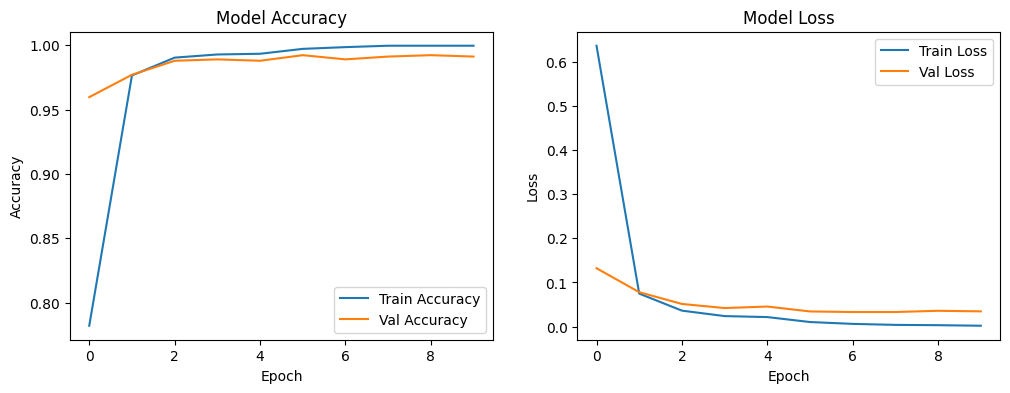

In [19]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [20]:
def visualize_predictions(x_test, y_test, model, count=5):
    if x_test.shape[0] == 0 or y_test.shape[0] == 0:
        print("Warning: Test data (x_test or y_test) is empty. Cannot visualize predictions.")
        return

    plt.figure(figsize=(15, 5))
    predictions = model.predict(x_test[:count])

    for i in range(count):
        plt.subplot(1, count, i + 1)

        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

        pred_label = np.argmax(predictions[i])
        true_label = np.argmax(y_test[i])

        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis('off')

    plt.show()

visualize_predictions(x_test, y_test, model)